# Project: Housing Prices in Nigeria

### By: Charity Okpanachi

# **Objective:**
### The objective of this project is to analyze real estate listings across Nigeria to understand the key factors that influence property prices. Specifically, the project aims to determine whether location or property size play a greater role in driving pricing patterns.

##  Environment Setup and Libraries

In [1]:
import pandas as pd   
import numpy as np    
import re             

# For visualization
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
# Loading dataset
housing_data = pd.read_csv("Nigeria Housing Properties Dataset.csv")
housing_data.head(2)

,Location,Currency,Price,Contact,Bedrooms,Realtor,Bathrooms,Title,Description,Parking Spaces,Toilets
0,"Urban Prime Three Phase 2 Estate, Ogombo, Ajah...",₦,"150,000,000",8067495852,5.0,Lake Pad Ventures,6.0,Luxury 5 Bedrooms Semi-detached Duplex,Hurry now!\nfor sale\nluxury 5 bedroom on two ...,5.0,7.0
1,"Ikoyi, Lagos",$,"2,800,000",7065266133,6.0,Bera Deals,6.0,Luxury 6 Bedrooms Penthouse Condo,Direct brief from the owner\n- the detailed vi...,NaN,7.0


### Inspect Dataset

In [3]:
# Check the number of rows and columns
housing_data.shape

(50247, 11)

In [4]:
#Check column names
housing_data.columns.to_list()

['Location',
 'Currency',
 'Price',
 'Contact',
 'Bedrooms',
 'Realtor',
 'Bathrooms',
 'Title',
 'Description',
 'Parking Spaces',
 'Toilets']

In [5]:
# Check datatypes and non-null count
housing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50247 entries, 0 to 50246
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Location        50247 non-null  object 
 1   Currency        50247 non-null  object 
 2   Price           50247 non-null  object 
 3   Contact         50247 non-null  object 
 4   Bedrooms        49325 non-null  float64
 5   Realtor         50246 non-null  object 
 6   Bathrooms       42697 non-null  float64
 7   Title           50247 non-null  object 
 8   Description     50247 non-null  object 
 9   Parking Spaces  25198 non-null  float64
 10  Toilets         44069 non-null  float64
dtypes: float64(4), object(7)
memory usage: 4.2+ MB


In [6]:
housing_data.head(2)

,Location,Currency,Price,Contact,Bedrooms,Realtor,Bathrooms,Title,Description,Parking Spaces,Toilets
0,"Urban Prime Three Phase 2 Estate, Ogombo, Ajah...",₦,"150,000,000",8067495852,5.0,Lake Pad Ventures,6.0,Luxury 5 Bedrooms Semi-detached Duplex,Hurry now!\nfor sale\nluxury 5 bedroom on two ...,5.0,7.0
1,"Ikoyi, Lagos",$,"2,800,000",7065266133,6.0,Bera Deals,6.0,Luxury 6 Bedrooms Penthouse Condo,Direct brief from the owner\n- the detailed vi...,NaN,7.0


* I performed an initial inspection of the dataset to understand its size, structure, column types, and missing values. This will help identify which variables require cleaning and transformation before analysis. The dataset has **50,247** rows, and **11** columns, and missing values in some columns.

### Data Cleaning and Standardization

In [7]:
# Check for duplicates
housing_data.duplicated().sum()

0

In [8]:
# Cleaning coloumn names to ensure there are no white spaces
housing_data.columns = housing_data.columns.str.strip()
housing_data.columns

Index(['Location', 'Currency', 'Price', 'Contact', 'Bedrooms', 'Realtor',
       'Bathrooms', 'Title', 'Description', 'Parking Spaces', 'Toilets'],
      dtype='object')

In [9]:
# Viewing the string columns
housing_data.select_dtypes(include="object").head(2)

,Location,Currency,Price,Contact,Realtor,Title,Description
0,"Urban Prime Three Phase 2 Estate, Ogombo, Ajah...",₦,"150,000,000",8067495852,Lake Pad Ventures,Luxury 5 Bedrooms Semi-detached Duplex,Hurry now!\nfor sale\nluxury 5 bedroom on two ...
1,"Ikoyi, Lagos",$,"2,800,000",7065266133,Bera Deals,Luxury 6 Bedrooms Penthouse Condo,Direct brief from the owner\n- the detailed vi...


In [10]:
# Cleaning text values also to ensure there are no white spaces
str_cols = housing_data.select_dtypes(include="object").columns

housing_data[str_cols] = housing_data[str_cols].apply(lambda col: col.str.strip())

In [11]:
housing_data.select_dtypes(include="object").head(2)

,Location,Currency,Price,Contact,Realtor,Title,Description
0,"Urban Prime Three Phase 2 Estate, Ogombo, Ajah...",₦,"150,000,000",8067495852,Lake Pad Ventures,Luxury 5 Bedrooms Semi-detached Duplex,Hurry now!\nfor sale\nluxury 5 bedroom on two ...
1,"Ikoyi, Lagos",$,"2,800,000",7065266133,Bera Deals,Luxury 6 Bedrooms Penthouse Condo,Direct brief from the owner\n- the detailed vi...


In [12]:
# Cleaning Price column to remove the comma
housing_data["Price"] = housing_data["Price"].str.replace(",", "")

# Convert Price column to float datatype
housing_data["Price"] = housing_data["Price"].astype(float)

In [13]:
housing_data["Price"].head(2)

0    150000000.0
1      2800000.0
Name: Price, dtype: float64

In [14]:
housing_data.select_dtypes(include="object").head(2)

,Location,Currency,Contact,Realtor,Title,Description
0,"Urban Prime Three Phase 2 Estate, Ogombo, Ajah...",₦,8067495852,Lake Pad Ventures,Luxury 5 Bedrooms Semi-detached Duplex,Hurry now!\nfor sale\nluxury 5 bedroom on two ...
1,"Ikoyi, Lagos",$,7065266133,Bera Deals,Luxury 6 Bedrooms Penthouse Condo,Direct brief from the owner\n- the detailed vi...


In [15]:
# View numerical columns
housing_data.select_dtypes(exclude="object").head()

,Price,Bedrooms,Bathrooms,Parking Spaces,Toilets
0,1.500000e+08,5.0,6.0,5.0,7.0
1,2.800000e+06,6.0,6.0,NaN,7.0
2,1.400000e+09,6.0,NaN,NaN,7.0
3,2.000000e+08,4.0,4.0,NaN,4.0
4,2.100000e+08,5.0,5.0,NaN,6.0


In [16]:
# Convert count-like columns to nullable integers
count_cols = ["Bedrooms", "Bathrooms", "Parking Spaces", "Toilets"]

for col in count_cols:
    housing_data[col] = housing_data[col].astype("Int64")

housing_data[count_cols].dtypes

Bedrooms          Int64
Bathrooms         Int64
Parking Spaces    Int64
Toilets           Int64
dtype: object

In [17]:
housing_data.dtypes

Location           object
Currency           object
Price             float64
Contact            object
Bedrooms            Int64
Realtor            object
Bathrooms           Int64
Title              object
Description        object
Parking Spaces      Int64
Toilets             Int64
dtype: object

In [18]:
# Inspect currency column
housing_data["Currency"].value_counts()

₦    49266
$      981
Name: Currency, dtype: int64

In [19]:
# Check if there are missing values in the column
housing_data["Currency"].isnull().sum()

0

* I cleaned and standardized the dataset by removing formatting issues, fixing data types, handling text inconsistencies, and converting price and count variables into analysis-ready numeric formats.

## Feature Engineering

###    Currency Normalization

In [20]:
# Convert all prices to NGN, assuming $1 is equal to ₦1500

usd_to_ngn = 1500 # Fixed exchange rate assumption

def convert_to_ngn(price, currency): # function that converts price only if needed
    if currency == "$":
        return price * usd_to_ngn # convert dollar prices to naira
    else:
        return price  # leaves naira prices unchanged
    
# Create a new column of price
housing_data["Price_NGN"] = housing_data.apply(
    lambda row: convert_to_ngn(row["Price"], row["Currency"]), axis=1   # applies the function row by row
)

In [21]:
housing_data[["Price", "Currency", "Price_NGN"]].head(10)

,Price,Currency,Price_NGN
0,1.500000e+08,₦,1.500000e+08
1,2.800000e+06,$,4.200000e+09
2,1.400000e+09,₦,1.400000e+09
3,2.000000e+08,₦,2.000000e+08
4,2.100000e+08,₦,2.100000e+08
5,1.800000e+08,₦,1.800000e+08
6,2.500000e+08,₦,2.500000e+08
7,9.400000e+07,₦,9.400000e+07
8,2.200000e+08,₦,2.200000e+08
9,9.500000e+07,₦,9.500000e+07


* To ensure price comparability, I converted all listings to Nigerian Naira using a fixed USD–NGN exchange rate and created a normalized price column for analysis.

### Text Mining and Size Extraction

In [22]:
housing_data["Description"].head()

0    Hurry now!\nfor sale\nluxury 5 bedroom on two ...
1    Direct brief from the owner\n- the detailed vi...
2    Direct brief / direct instruction from the own...
3    For sale in ologolo\n4 bedroom fully detached ...
4    5 bed ikate n215m\nluxury 5 bedroom semidetach...
Name: Description, dtype: object

In [23]:
housing_data["Description"].isnull().sum()

0

In [24]:
# Extract property size from description text

def extract_size(description): # function that extract size
    if pd.isna(description): # handles missing values if there is any
        return np.nan
    
    desc = description.lower() # standardizing column
    
    # Look for square meter patterns and extract them
    sqm_match = re.search(r'(\d+(?:\.\d+)?)\s*(sqm|sq\.m|square meters?)', desc)
    if sqm_match:
        return float(sqm_match.group(1)) # extract square meters and convert the number to float
    
    # Look for plot-based patterns (assuming 1 plot = 450sqm)
    plot_match = re.search(r'(\d+)\s*plot', desc)
    if plot_match:
        return float(plot_match.group(1)) * 450 # convert to square meters
    
    # Look for acres-based pattern (assuming 1 acre = 4046.86 sqm)
    acre_match = re.search(r'(\d+(?:\.\d+)?)\s*acre', desc)
    if acre_match:
        return float(acre_match.group(1)) * 4046.86 # convert to square meters
    
    return np.nan #if no size information is found, return as missing value

housing_data["Size_sqm"] = housing_data["Description"].apply(extract_size) # apply extraction to the entire dataset

In [25]:
housing_data[["Description", "Size_sqm"]].head(10)

,Description,Size_sqm
0,Hurry now!\nfor sale\nluxury 5 bedroom on two ...,250.0
1,Direct brief from the owner\n- the detailed vi...,NaN
2,Direct brief / direct instruction from the own...,NaN
3,For sale in ologolo\n4 bedroom fully detached ...,NaN
4,5 bed ikate n215m\nluxury 5 bedroom semidetach...,NaN
5,*direct brief fir sale*\n*for sale in agungi*\...,500.0
6,For sale in lekki phase 1\n4 bedroom terrace d...,NaN
7,Good value properly finished 4 bed fully detac...,NaN
8,4 bedroom fully detached duplex for sale.\name...,NaN
9,A fully detached 6 bedroom family home built w...,NaN


In [26]:
housing_data["Size_sqm"].isnull().sum()

45433

* Because property size was not provided as a structured variable, I extracted size information from listing descriptions using regular expressions and converted different land units into square meters to create a comparable size feature.

### State extraction from Location using string split

In [27]:
# View the location column
housing_data["Location"].head(20)

0     Urban Prime Three Phase 2 Estate, Ogombo, Ajah...
1                                          Ikoyi, Lagos
2             Pinnock Beach Estate, Osapa, Lekki, Lagos
3           Oseni Mayegun Street, Ologolo, Lekki, Lagos
4                      Ikate Lekki, Ikate, Lekki, Lagos
5                                  Agungi, Lekki, Lagos
6          Off Freedom Way, Lekki Phase 1, Lekki, Lagos
7                                           Ajah, Lagos
8                          Ikate Elegushi, Lekki, Lagos
9                 Agbovu Estate, Amawbia, Awka, Anambra
10                             Karsana, Gwarinpa, Abuja
11                          Dubai Estate, Awka, Anambra
12                                  Allen, Ikeja, Lagos
13           Awka Millenium City Phase 1, Awka, Anambra
14                                         Kubwa, Abuja
15                                      Gwarinpa, Abuja
16                                  Ikate, Lekki, Lagos
17                                  Ikate, Lekki

In [28]:
# Extract state from location using string split
def extract_state(location):
    if not isinstance(location, str):
        return np.nan
    
    # split by comma and take the last part
    state = location.split(",")[-1].strip()
    
    return state

housing_data["State"] = housing_data["Location"].apply(extract_state)

In [29]:
housing_data["State"].head(10)

0      Lagos
1      Lagos
2      Lagos
3      Lagos
4      Lagos
5      Lagos
6      Lagos
7      Lagos
8      Lagos
9    Anambra
Name: State, dtype: object

In [30]:
housing_data["State"].value_counts()

Lagos          39313
Abuja           7853
Oyo             1083
Rivers           655
Ogun             506
Enugu            371
Edo              123
Imo               75
Delta             54
Osun              51
Ondo              39
Akwa Ibom         28
Anambra           24
Kwara             19
Nasarawa           8
Ekiti              7
Abia               7
Kaduna             7
Plateau            6
Kogi               5
Kano               4
Ebonyi             3
Jigawa             2
Cross River        1
Zamfara            1
Benue              1
Niger              1
Name: State, dtype: int64

* I extracted state-level geographic information from unstructured location column to enable regional price comparisons.

### Feature Refinement

In [31]:
# Data Quality Check (Feature Validation & Outlier Detection)
housing_data["Size_sqm"].describe()

count    4.814000e+03
mean     7.534611e+08
std      5.227732e+10
min      0.000000e+00
25%      4.500000e+02
50%      6.000000e+02
75%      9.000000e+02
max      3.627157e+12
Name: Size_sqm, dtype: float64

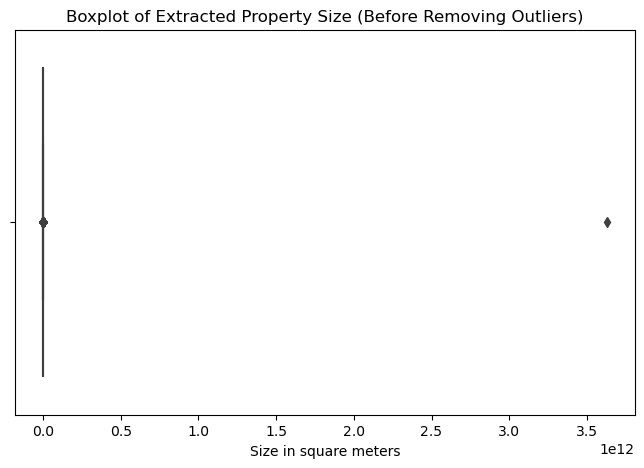

In [32]:
# Visualization using boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=housing_data["Size_sqm"])
plt.title("Boxplot of Extracted Property Size (Before Removing Outliers)")
plt.xlabel("Size in square meters")
plt.show()

* After extracting property size from text descriptions, I evaluated its distribution to detect unrealistic values and data extraction errors before proceeding with analysis. A few descriptions contained numbers that regex mistakenly captured as land size (e.g., phone numbers, prices, reference IDs). The extracted size feature contains extreme outliers that must be removed before analysis.

### Remove Outliers

In [33]:
# Remove unrealistic property sizes

# Define reasonable bounds for residential properties in sqm
MIN_SIZE = 50
MAX_SIZE = 10_000

housing_data['Size_sqm_clean'] = housing_data['Size_sqm'].where(
    (housing_data['Size_sqm'] >= MIN_SIZE) &
    (housing_data['Size_sqm'] <= MAX_SIZE)
)

In [34]:
# Check the cleaned distribution
housing_data['Size_sqm_clean'].describe()

count    4654.000000
mean      839.560531
std       850.279022
min        50.000000
25%       450.000000
50%       601.080000
75%       900.000000
max      9900.000000
Name: Size_sqm_clean, dtype: float64

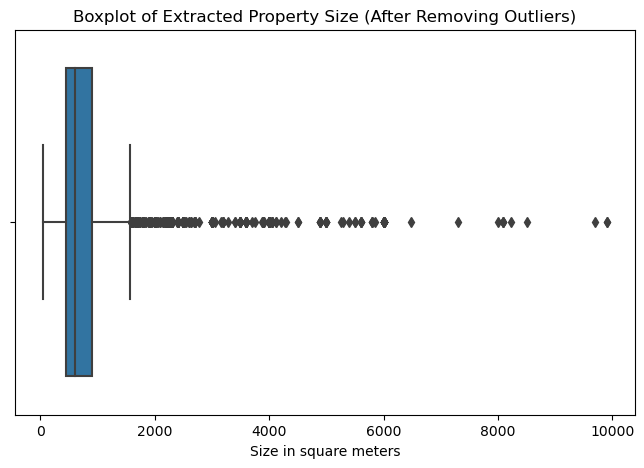

In [35]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=housing_data["Size_sqm_clean"])
plt.title("Boxplot of Extracted Property Size (After Removing Outliers)")
plt.xlabel("Size in square meters")
plt.show()

* I removed unrealistic property size values using domain-based thresholds and created a cleaned size feature for reliable analysis.

## Create analysis ready subset

### Data Preparation for Analysis 

In [36]:
housing_data.columns

Index(['Location', 'Currency', 'Price', 'Contact', 'Bedrooms', 'Realtor',
       'Bathrooms', 'Title', 'Description', 'Parking Spaces', 'Toilets',
       'Price_NGN', 'Size_sqm', 'State', 'Size_sqm_clean'],
      dtype='object')

In [37]:
# Create a new DataFrame and ensure no missing values

housing_analysis_data = housing_data[
    housing_data["Location"].notna() &
    housing_data["Price_NGN"].notna() &
    housing_data["Size_sqm_clean"].notna() &
    housing_data["State"].notna()
].copy()

In [38]:
housing_analysis_data.shape

(4654, 15)

In [39]:
housing_analysis_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4654 entries, 0 to 50223
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Location        4654 non-null   object 
 1   Currency        4654 non-null   object 
 2   Price           4654 non-null   float64
 3   Contact         4654 non-null   object 
 4   Bedrooms        4362 non-null   Int64  
 5   Realtor         4654 non-null   object 
 6   Bathrooms       3616 non-null   Int64  
 7   Title           4654 non-null   object 
 8   Description     4654 non-null   object 
 9   Parking Spaces  2259 non-null   Int64  
 10  Toilets         3731 non-null   Int64  
 11  Price_NGN       4654 non-null   float64
 12  Size_sqm        4654 non-null   float64
 13  State           4654 non-null   object 
 14  Size_sqm_clean  4654 non-null   float64
dtypes: Int64(4), float64(4), object(7)
memory usage: 599.9+ KB


* I created a final analysis dataset by filtering only records with complete price, size, and location information to ensure reliable statistical analysis.

## Exploratory Data Analysis 

### Explore relationship between size and price: Does property size influence housing prices in Nigeria?

In [40]:
# Correlation between property size and price

size_price_corr = housing_analysis_data["Size_sqm_clean"].corr(housing_analysis_data["Price_NGN"])

round(size_price_corr, 4)

-0.0026

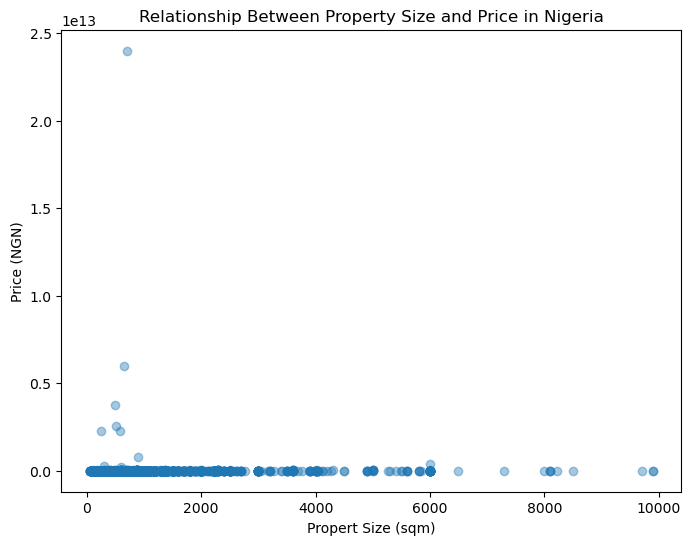

In [41]:
# Scatter plot of size vs price

plt.figure(figsize=(8,6))
plt.scatter(
    housing_analysis_data["Size_sqm_clean"],
    housing_analysis_data["Price_NGN"],
    alpha=0.4
)

plt.xlabel("Propert Size (sqm)")
plt.ylabel("Price (NGN)")
plt.title("Relationship Between Property Size and Price in Nigeria")

plt.show();

 * Property size has no meaningful relationship with price in Nigeria. Practically zero, indicating that larger homes are not necessarily more expensive in the Nigerian housing market.

### Relationship Between Number of Bedrooms and Property Size

In [42]:
bedroom_size = housing_analysis_data[["Size_sqm_clean", "Bedrooms"]].dropna().corr().iloc[0,1]
round(bedroom_size, 2)

0.18

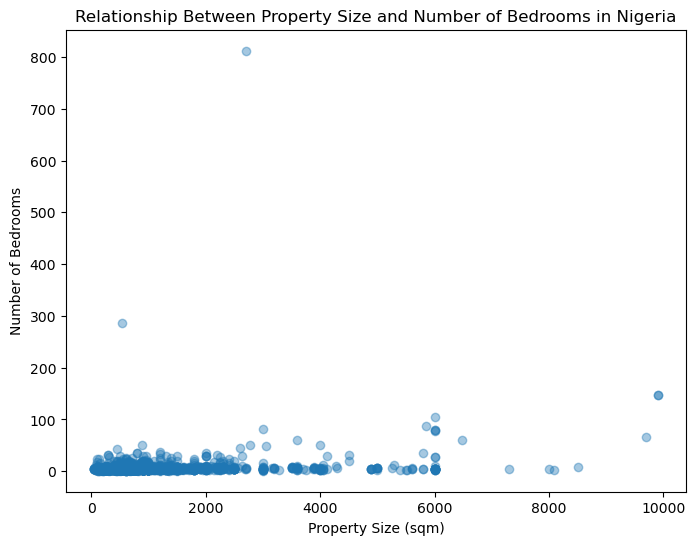

In [43]:
# Visualization
plot_data = housing_analysis_data[["Size_sqm_clean", "Bedrooms"]].dropna()

plt.figure(figsize=(8,6))
plt.scatter(
    plot_data["Size_sqm_clean"],
    plot_data["Bedrooms"],
    alpha=0.4
)

plt.xlabel("Property Size (sqm)")
plt.ylabel("Number of Bedrooms")
plt.title("Relationship Between Property Size and Number of Bedrooms in Nigeria")

plt.show();


* The correlation between property size and number of bedrooms is weak (0.18), indicating that larger properties in Nigeria do not necessarily have more bedrooms. This suggests that developers often prioritize room size, layout, and luxury features over simply increasing bedroom count. As a result, the number of bedrooms alone is not a reliable indicator of property value.

### Analyze Price difference by Location

### Location vs Price - State Level

In [44]:
# Median house price by state

state_price_summary = (
    housing_analysis_data
    .groupby("State")["Price_NGN"]
    .median()
    .sort_values(ascending=False)
)
state_price_summary

State
Abuja        470000000.0
Lagos        387500000.0
Abia         190000000.0
Delta        190000000.0
Edo          150000000.0
Plateau      140000000.0
Imo          130000000.0
Anambra      130000000.0
Rivers       100000000.0
Enugu        100000000.0
Oyo           80000000.0
Akwa Ibom     73500000.0
Ekiti         65000000.0
Nasarawa      45000000.0
Kogi          45000000.0
Ondo          44000000.0
Kwara         43000000.0
Ogun          40000000.0
Osun          17000000.0
Name: Price_NGN, dtype: float64

* A typical home in Abuja costs almost 30 times more than in Osun. Where a house is located matters far more than how big it is.

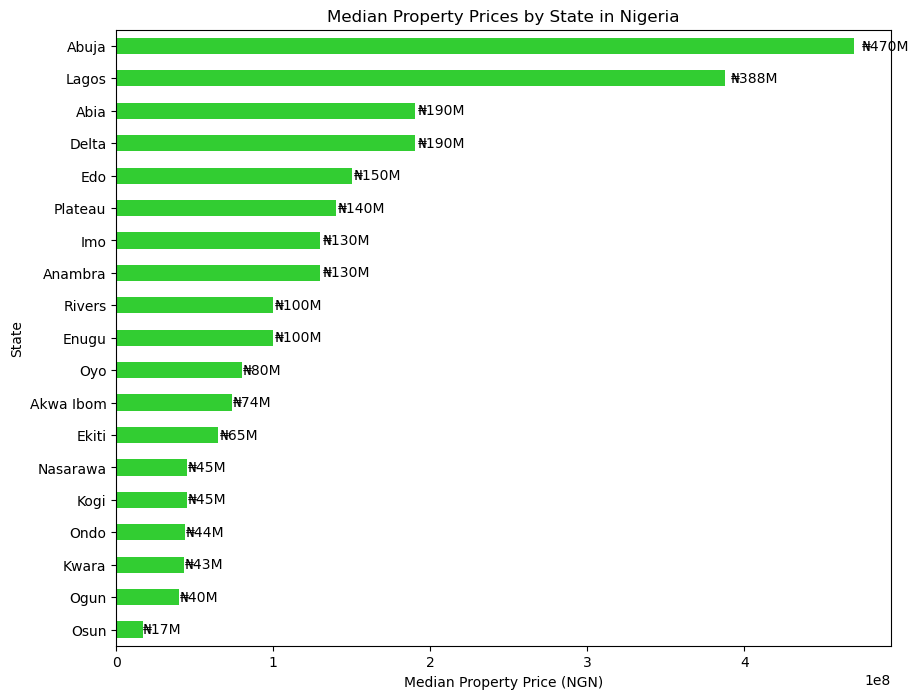

In [45]:
# Visualization
state_price_summary.sort_values().plot(
    kind="barh",
    figsize=(10, 8),
    color="limegreen"
)

plt.xlabel("Median Property Price (NGN)")
plt.ylabel("State")
plt.title("Median Property Prices by State in Nigeria")

# Add value label
ax = plt.gca()

for p in ax.patches:
    width = p.get_width()
    ax.text(
        width * 1.01,                     # slightly after bar
        p.get_y() + p.get_height() / 2,    # center of bar
        f"₦{width/1e6:.0f}M",              # format in millions
        va="center"
    )


plt.show();

* I used median house prices instead of average prices because real estate data contains extreme luxury properties that distort the mean. Median gives a more realistic picture of what a typical home costs in each Nigerian state.
* The State-level analysis showed enormous price variation across Nigeria, with **Abuja** and **Lagos** commanding prices several times higher than most other states, confirming that location is the dominant driver of housing prices.”

## Feature Engineering (Neighborhood / Area Extraction)

### Extract Area from the Location column

In [46]:
# Extract Area (e.g., Lekki, Ikoyi, Ajah) from Location

housing_analysis_data['Area'] = housing_analysis_data['Location'].apply(
    lambda x: x.split(',')[-2].strip()
)

In [47]:
housing_analysis_data[["Location", "State", "Area"]].tail(10)

,Location,State,Area
49983,"At Gra Phase 1, Port Harcourt, Rivers",Rivers,Port Harcourt
50011,"Ajah, Lekki, Lagos",Lagos,Lekki
50029,"Ajah, Lagos",Lagos,Ajah
50062,"Lekki Phase 1 Lekki Phase Lagos, Lekki Phase 1...",Lagos,Lekki
50068,"Off Adewunmi Adebimpe Drive Lekki Phase 1, Lek...",Lagos,Lekki
50086,"Pinnock Beach Estate, Osapa, Lekki, Lagos",Lagos,Lekki
50088,"Sam Shonibare, Surulere, Lagos",Lagos,Surulere
50094,"Mko Abiola Crescent, Off Toyin Street, Alausa,...",Lagos,Ikeja
50186,"Abijo, Lekki, Lagos",Lagos,Lekki
50223,"Police Sign Board, Lugbe District, Abuja",Abuja,Lugbe District


* I extracted neighborhood-level location data from the location column to enable analysis of price differences within states.

### Data Subsetting (High-Value Market Focus)

#### Filter to only Lagos and Abuja States

In [48]:
# Create a subset for Lagos and Abuja only

lagos_abuja_data = housing_analysis_data[
    housing_analysis_data['State'].isin(['Lagos', 'Abuja'])
]

In [49]:
lagos_abuja_data["State"].value_counts()

Lagos    2916
Abuja    1073
Name: State, dtype: int64

* Filtered the dataset to focus on **Lagos** and **Abuja**, the two highest-value housing markets in Nigeria, in order to analyze neighborhood-level price differences.

### Area - Level Price Patterns (Lagos vs Abuja)

In [50]:
# Median price per area in Lagos & Abuja

area_price_median = (
    lagos_abuja_data
    .groupby(["State", "Area"])["Price_NGN"]
    .median()
    .sort_values(ascending=False)
)

In [51]:
housing_analysis_data[["State", "Area"]]

,State,Area
0,Lagos,Ajah
5,Lagos,Lekki
21,Lagos,Ikoyi
46,Lagos,Ajah
48,Lagos,Lekki
...,...,...
50086,Lagos,Lekki
50088,Lagos,Surulere
50094,Lagos,Ikeja
50186,Lagos,Lekki


In [52]:
area_price_median.head(10)

State  Area                
Lagos  Ikoyi                   3.000000e+09
Abuja  Maitama District        2.500000e+09
Lagos  Eko Atlantic City       1.755000e+09
       Victoria Island (VI)    1.500000e+09
Abuja  Gudu                    1.300000e+09
       Asokoro District        1.250000e+09
       Wuse 2                  1.200000e+09
Lagos  Lagos Island            1.000000e+09
Abuja  Guzape District         9.000000e+08
Lagos  Apapa                   8.000000e+08
Name: Price_NGN, dtype: float64

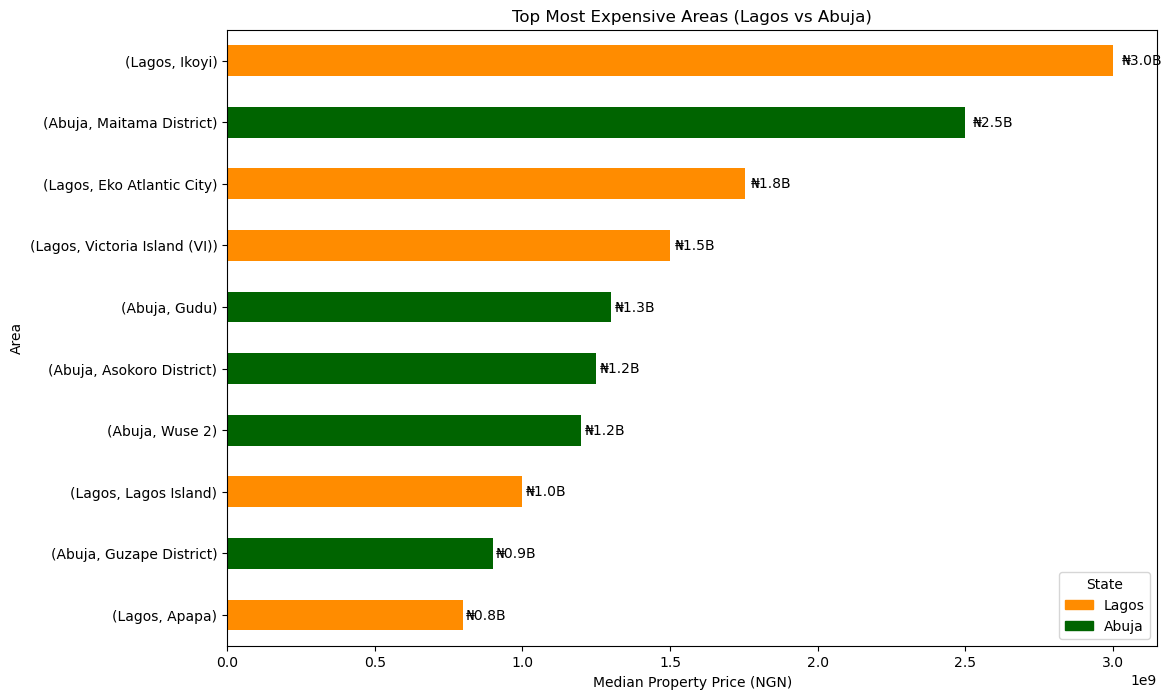

In [53]:
# Visualizing top 10 most expensive areas
top10_areas = area_price_median.head(10)

# Sorting
top10_sorted = top10_areas.sort_values()

# Extract state from the index
states = [idx[0] for idx in top10_sorted.index]

# Assign colors based on state
colors = ["darkorange" if state == "Lagos" else "darkgreen" for state in states]

# Plot
top10_sorted.plot(
    kind='barh',
    figsize=(12,8),
    color=colors
)

plt.xlabel("Median Property Price (NGN)")
plt.ylabel("Area")
plt.title("Top Most Expensive Areas (Lagos vs Abuja)")

# Legend
import matplotlib.patches as mpatches
plt.legend(handles=[
    mpatches.Patch(color="darkorange", label="Lagos"),
    mpatches.Patch(color="darkgreen", label="Abuja")
], title="State")

# Add value labels
ax = plt.gca()
for p in ax.patches:
    width = p.get_width()
    ax.text(width * 1.01, p.get_y() + p.get_height()/2,
            f"₦{width/1e9:.1f}B", va="center")


plt.show()


* Neighborhood-level analysis revealed extreme price differences within Lagos and Abuja, with areas such as Ikoyi in Lagos and Maitama in Abuja commanding multi-billion-naira median prices, confirming that micro-location is the strongest driver of housing prices in Nigeria not even state alone.

In [54]:
housing_analysis_data.columns

Index(['Location', 'Currency', 'Price', 'Contact', 'Bedrooms', 'Realtor',
       'Bathrooms', 'Title', 'Description', 'Parking Spaces', 'Toilets',
       'Price_NGN', 'Size_sqm', 'State', 'Size_sqm_clean', 'Area'],
      dtype='object')

In [55]:
state_avg_size = housing_analysis_data.groupby("State")["Size_sqm_clean"].mean().sort_values(ascending=False)
state_avg_size

State
Delta        3728.571429
Kogi         3000.000000
Anambra      1836.000000
Kwara        1575.000000
Abia         1350.000000
Plateau      1333.333333
Osun         1310.000000
Edo          1241.221429
Abuja        1061.249438
Ondo          970.000000
Akwa Ibom     935.250000
Oyo           934.005500
Rivers        872.538568
Nasarawa      800.000000
Lagos         748.455921
Enugu         647.864198
Imo           635.052632
Ogun          626.793141
Ekiti         600.000000
Name: Size_sqm_clean, dtype: float64

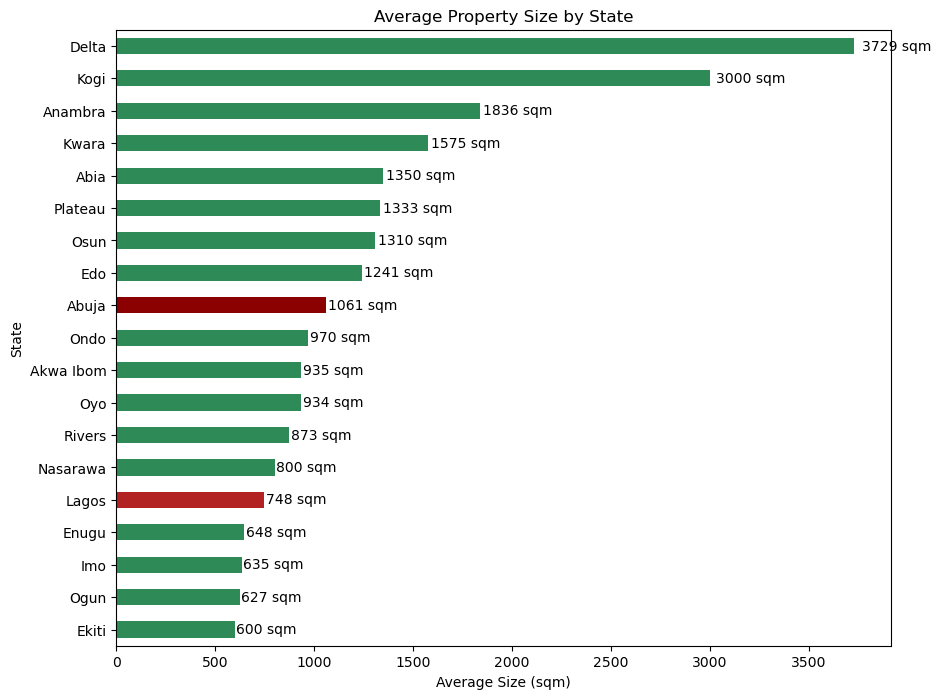

In [56]:
# Visualization

state_avg_size_sorted = state_avg_size.sort_values() # Sort the data 

# Assign colors
colors = [
    "firebrick" if state == "Lagos"
    else "darkred" if state == "Abuja"
    else "seagreen"
    for state in state_avg_size_sorted.index
]

state_avg_size_sorted.plot(
    kind="barh", 
    figsize=(10,8), 
    title="Average Property Size by State",
    color=colors
)
plt.xlabel("Average Size (sqm)")

# Add value labels
ax = plt.gca()
for p in ax.patches:
    width = p.get_width()
    ax.text(
        width * 1.01, 
        p.get_y() + p.get_height()/2,
        f"{width:.0f} sqm", 
        va="center"
    )


plt.show()

* Interestingly, **Lagos and Abuja** have small average property size **(748 sqm and 1061 sqm)** respectively despite being the most expensive housing market. Meanwhile, states like Delta and Kogi have much larger homes but significantly lower prices. This confirms that housing prices in Nigeria are primarily driven by location rather than physical size.”

In [57]:
# Save dataset
housing_analysis_data.to_csv("Nigerian Housing Property Analysis Dataset.csv", index=False)

## Conclusion

### This project demonstrates that in Nigeria, where a property is located matters far more than how big it is. From state level down to individual neighborhoods, location is the dominant driver of housing prices.
#### This insight is critical for:
* Real estate investors
* Home buyers
* Urban planners
* Housing policy design


## Business and Policy Implications

### For Real Estate Developers and Investors
* The results suggest that developers should focus more on where a property is located rather than only on how large it is. States such as Lagos and Abuja command much higher prices, even for smaller properties, while larger homes in other states sell for much less. This means investing in high-demand locations is more profitable than simply building bigger houses.

### For Home Buyers
* Buyers who are flexible about location can get more space for their money by purchasing properties outside major cities. 

### For Policymakers
* The large price gap between states show that housing demand are highly concentrated in a few states, which also mean high economic activities in those states. In other words:
- People migrate more to Lagos/Abuja
- Housing prices increase in theses locations
- Overcrowding happens

#### Government can use this insight to: 
- Invest in infrastructure and development in lower-priced states to encourages businesses to operate outside major cities.
- Reduce pressure on housing in Locations like Lagos and Abuja and promote more balanced growth.